In [49]:
import numpy as np 
from sklearn import datasets
import sklearn
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [50]:
digits = datasets.load_digits()         #download the data 
print(digits.images.shape)
print(digits.keys())

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [51]:
#let's choose 100 numbers from the dataset
np.random.seed(42)
mychoices = np.random.choice(digits.images.shape[0],100)

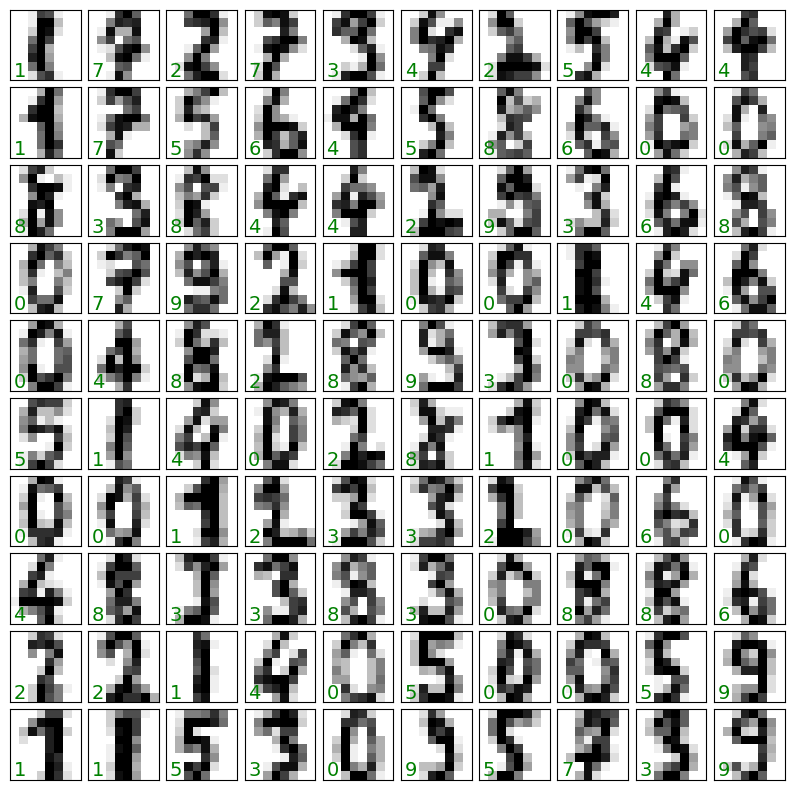

In [52]:
fig, axes = plt.subplots(10,10, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

In [53]:
print(digits.data.shape)

# The images themselves
print(digits.images[1]) #of the 2nd image 

# The data for use in our algorithms
print(digits.data[1])

# The labels
print(digits.target[mychoices]) #labels of my set 
print(digits.target_names)


(1797, 64)
[[ 0.  0.  0. 12. 13.  5.  0.  0.]
 [ 0.  0.  0. 11. 16.  9.  0.  0.]
 [ 0.  0.  3. 15. 16.  6.  0.  0.]
 [ 0.  7. 15. 16. 16.  2.  0.  0.]
 [ 0.  0.  1. 16. 16.  3.  0.  0.]
 [ 0.  0.  1. 16. 16.  6.  0.  0.]
 [ 0.  0.  1. 16. 16.  6.  0.  0.]
 [ 0.  0.  0. 11. 16. 10.  0.  0.]]
[ 0.  0.  0. 12. 13.  5.  0.  0.  0.  0.  0. 11. 16.  9.  0.  0.  0.  0.
  3. 15. 16.  6.  0.  0.  0.  7. 15. 16. 16.  2.  0.  0.  0.  0.  1. 16.
 16.  3.  0.  0.  0.  0.  1. 16. 16.  6.  0.  0.  0.  0.  1. 16. 16.  6.
  0.  0.  0.  0.  0. 11. 16. 10.  0.  0.]
[1 7 2 7 3 4 2 5 4 4 1 7 5 6 4 5 8 6 0 0 8 3 8 4 4 2 9 3 6 8 0 7 9 2 1 0 0
 1 4 6 0 4 8 2 8 9 3 0 8 0 5 1 4 0 2 8 1 0 0 4 0 0 1 2 3 3 2 0 6 0 4 8 3 3
 8 3 0 8 8 6 2 2 1 4 0 5 0 0 5 9 1 1 5 3 0 9 5 7 3 9]
[0 1 2 3 4 5 6 7 8 9]


In [54]:
N=2 #number of dimensions 

iso = Isomap(n_components=N, n_neighbors=10)            #Iso estimator 
data_red = iso.fit_transform(digits.data)
print(digits.data.shape, "-->", data_red.shape)


(1797, 64) --> (1797, 2)


Now we have a dataset with only two features

In [55]:
"""Create an N-bin discrete colormap from the specified input map""" 

def discrete_cmap(N, base_cmap=None):
    base = plt.colormaps[base_cmap]
    color_list = base(np.linspace(0, 1, N))
    cmap_name = base.name + str(N)
    return base.from_list(cmap_name, color_list, N)

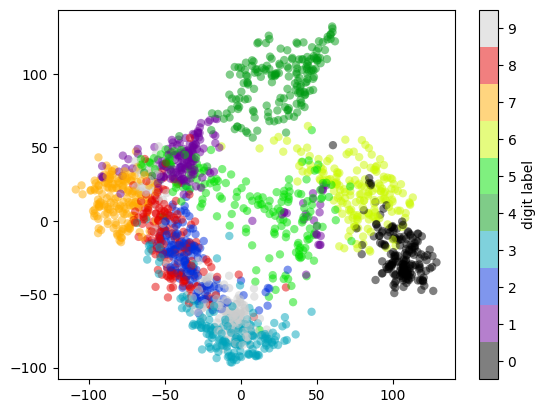

In [56]:
#plot the 2 component of data red, with the known labels 
plt.scatter(data_red[:,0], data_red[:,1], c=digits.target, edgecolor='none', alpha=0.5, cmap=discrete_cmap(10,'nipy_spectral'));

# Add the color bar
plt.colorbar(label='digit label', ticks=range(10))

# Make it clear which color goes with which label
plt.clim(-0.5, 9.5)

###  Part 3: Supervised, classification

First of all split the data in tranining dataset and test set.

In [57]:
#we use the reduced data 
Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target, test_size=0.2, random_state=18)
print(Xtrain.shape, Xtest.shape)

(1437, 64) (360, 64)


Let's perform the classification on the training set

In [58]:
# In roder to converge it uses an high number of iterations
clf = LogisticRegression(penalty='l2', max_iter=10000,solver='sag')    

clf.fit(Xtrain, ytrain)


LogisticRegression(max_iter=10000, solver='sag')

Now I try to predict on the TRAIN SET

In [59]:
y_pred_train=clf.predict(Xtrain)           #in this way I find the predicted labels for the training set

acc=accuracy_score(ytrain, y_pred_train)

print(acc)
print(clf.score(Xtrain, ytrain)) #accuracy and score are the same thing 

1.0
1.0


Let's try with the TEST SET

In [60]:
y_pred_test=clf.predict(Xtest)           #in this way i find the predicted labels for the training set
acc2=accuracy_score(ytest, y_pred_test)
acc2

0.9694444444444444

Performing the Logistic Regression (It is a classification algorithm!) on the reduced data gives something strange with the accuracy 

### Confusion matrix

In [62]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(ytest, y_pred_test))


[[30  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  1  0]
 [ 0  1 30  0  0  0  0  0  0  0]
 [ 0  0  0 44  0  1  0  0  1  0]
 [ 0  1  0  0 39  0  0  0  0  0]
 [ 0  0  0  1  0 33  0  0  0  0]
 [ 0  0  0  0  0  1 41  0  0  0]
 [ 0  0  0  0  1  0  0 37  0  0]
 [ 0  2  0  0  0  0  0  0 29  0]
 [ 0  0  0  0  0  0  0  0  1 29]]


In [64]:
print(confusion_matrix(ytrain, y_pred_train))

[[148   0   0   0   0   0   0   0   0   0]
 [  0 144   0   0   0   0   0   0   0   0]
 [  0   0 146   0   0   0   0   0   0   0]
 [  0   0   0 137   0   0   0   0   0   0]
 [  0   0   0   0 141   0   0   0   0   0]
 [  0   0   0   0   0 148   0   0   0   0]
 [  0   0   0   0   0   0 139   0   0   0]
 [  0   0   0   0   0   0   0 141   0   0]
 [  0   0   0   0   0   0   0   0 143   0]
 [  0   0   0   0   0   0   0   0   0 150]]
